In [1]:
import sys
sys.path.append('../')
sys.path.append('../../')
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
file = 'pipi_2pt_nvec_64_tsrc_24_task1.h5'
with h5py.File(file) as f:
    data = f['/pipi_000/pipi/direct/cfg_400_tsrc_avg'][:]

print(data)
import matplotlib.pyplot 
plt.plot(np.arange(64), data, '.', )
plt.yscale('log')
plt.legend()
plt.savefig('pipi.jpg')


NameError: name 'h5py' is not defined

(2, 64)


/tmp/ipykernel_401198/1051541956.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


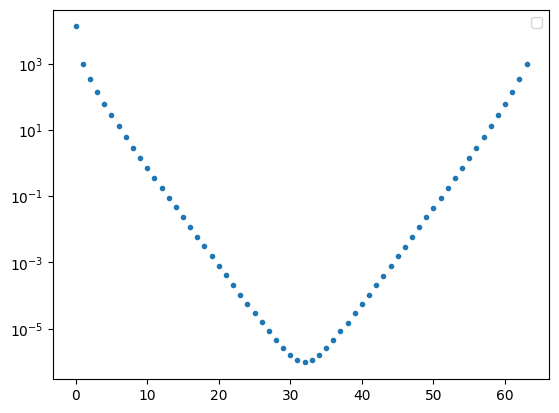

In [40]:
file = 'utils/dpi_test.h5'
data = np.zeros((2,64,24))
with h5py.File(file,'r') as f:
    for isrc,tsrc in enumerate(f['/Dpi_000/Dpi/6/']):
        t = int(tsrc.split('_')[1])
        cfg_list = list(f[f'/Dpi_000/Dpi/6/{tsrc}/'])
        for icfg, cfg in enumerate(sorted(cfg_list, key=lambda cfg: int(cfg[4:]))):
            cfg_data = np.array(f[f'/Dpi_000/Dpi/6/{tsrc}/{cfg}/cfg{icfg+1}'][:])
            data[icfg, :, t] = cfg_data
for i in range(24):
    data[:,:, i] = np.roll(data[:, :, i], -4*i, axis=1)
data = data.mean(axis=2)


print(data.shape)
import matplotlib.pyplot 
plt.plot(np.arange(64), data[1,:], '.')
plt.yscale('log')
plt.legend()
plt.savefig('pipi.jpg')
